<a href="https://colab.research.google.com/github/ankitbawne57-rgb/My-Project/blob/main/ANKIT_BAWNE_(_Enroll_0818IS231002_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ AI Cyber Defense System
### Multi-Agent Cybersecurity Pipeline: LangGraph + AutoGen + HuggingFace

---

## 🏗️ Architecture Overview

```
         ┌─────────────────────────────────────────────────────────┐
         │              AI CYBER DEFENSE PIPELINE                  │
         └─────────────────────────────────────────────────────────┘

  INPUT (Logs / Email / URL)
       │
       ▼
  ┌─────────┐      ┌──────────────────────────────────────────────┐
  │  INGEST │      │         LANGGRAPH ORCHESTRATOR               │
  │  NODE   │ ───► │                                              │
  └─────────┘      │  ┌─────────────┐    ┌──────────────────┐    │
                   │  │  Log Analysis│    │ Phishing Detect  │    │
                   │  │  (IsoForest) │    │ (Heuristics+ML)  │    │
                   │  └──────┬──────┘    └────────┬─────────┘    │
                   │         └──────────┬──────────┘             │
                   │                   ▼                          │
                   │    ┌──────────────────────────────┐          │
                   │    │    AUTOGEN MULTI-AGENT        │          │
                   │    │  ┌──────────┐ ┌──────────┐   │          │
                   │    │  │ Analyst  │ │  Critic  │   │          │
                   │    │  └──────────┘ └──────────┘   │          │
                   │    │        ┌────────────┐         │          │
                   │    │        │ SOC Manager│         │          │
                   │    │        └────────────┘         │          │
                   │    └──────────────────────────────┘          │
                   │                   ▼                          │
                   │    ┌──────────────────────────────┐          │
                   │    │  Threat Scoring + Response   │          │
                   │    │  Generation + Final Report   │          │
                   │    └──────────────────────────────┘          │
                   └──────────────────────────────────────────────┘
```

## 📦 Components
| Component | Technology | Purpose |
|-----------|-----------|---------|
| Orchestrator | **LangGraph** StateGraph | Manages pipeline flow & state |
| Agents | **AutoGen** ConversableAgent | Multi-agent threat discussion |
| LLM | **TinyLlama-1.1B** (HuggingFace) | Free, Colab-compatible LLM |
| Anomaly Detection | **Isolation Forest** | ML-based log anomaly detection |
| Phishing Scorer | Custom heuristics | Keyword + URL analysis |
| UI | **Gradio** | Interactive web interface |


## 🔧 Step 1: Install Dependencies


In [ ]:
# Install all required packages with versions compatible with Python 3.12
# Programmatic restart for Google Colab
#import os
#os.kill(os.getpid(), 9)
!pip install -q pyautogen
!pip install -q "pyautogen>=0.10.0"
!pip install -q "langgraph>=0.1.19"
!pip install -q "transformers>=4.38.0" accelerate
!pip install -q bitsandbytes
!pip install -q scikit-learn pandas numpy matplotlib
!pip install -q gradio
!pip install -q colorama
print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
✅ All packages installed successfully!


## 📦 Step 2: Imports & Configuration


In [ ]:
import os, re, json, random, hashlib, datetime, warnings, sys, subprocess, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import TypedDict, List, Optional, Dict, Any

# Ensure autogen is available and recognized by the kernel
try:
    import autogen
    from autogen import ConversableAgent
    print(f"✅ AutoGen version {getattr(autogen, '__version__', 'unknown')} imported successfully!")
except ImportError:
    print("🔄 Autogen not detected. Attempting to install and refresh path...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyautogen>=0.10.0"])
    importlib.invalidate_caches()
    try:
        import autogen
        from autogen import ConversableAgent
        print("✅ AutoGen installed and imported successfully!")
    except ImportError:
        print("⚠️ ERROR: Still cannot find 'autogen'.")
        print("👉 FIX: Click 'Runtime' -> 'Restart session' and run this cell again.")

from langgraph.graph import StateGraph, END
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── Device Check ─────────────────────────────────────────
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_LLM = True

print(f"🖥️  Device         : {DEVICE}")
print(f"🔥 PyTorch        : {torch.__version__}")
print(f"⚡ USE_LLM Mode   : {USE_LLM}")

🔄 Autogen not detected. Attempting to install and refresh path...
⚠️ ERROR: Still cannot find 'autogen'.
👉 FIX: Click 'Runtime' -> 'Restart session' and run this cell again.
🖥️  Device         : cuda
🔥 PyTorch        : 2.10.0+cu128
⚡ USE_LLM Mode   : True


## 🤗 Step 3: Load HuggingFace Model (TinyLlama)


In [ ]:
from transformers import pipeline as hf_pipeline_loader

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# Alternatives if TinyLlama is slow on your Colab:
# MODEL_NAME = "microsoft/phi-2"              (smarter, slower)
# MODEL_NAME = "facebook/opt-125m"            (fastest, weakest)
# MODEL_NAME = "distilgpt2"                   (fastest fallback)

hf_pipe = None

def load_model():
    global hf_pipe
    if not USE_LLM:
        print("⚡ DEMO MODE: Rule-based responses (no LLM loaded)")
        return
    print(f"📥 Loading {MODEL_NAME}...")
    print("   (This may take 1-3 min depending on Colab speed)")
    try:
        kwargs = dict(
            model=MODEL_NAME,
            max_new_tokens=256,
            pad_token_id=2,
        )
        if DEVICE == "cuda":
            kwargs["torch_dtype"] = torch.float16
            kwargs["device_map"] = "auto"
        else:
            kwargs["device_map"] = "cpu"
        hf_pipe = hf_pipeline_loader("text-generation", **kwargs)
        print(f"✅ Model loaded on {DEVICE}!")
    except Exception as e:
        print(f"⚠️  Model load failed: {e}")
        print("    → Falling back to rule-based DEMO MODE")
        hf_pipe = None


def llm_generate(system_prompt: str, user_prompt: str, max_tokens: int = 180) -> str:
    """Generate response using HF model, with rule-based fallback"""
    if hf_pipe is None:
        return _rule_based_fallback(system_prompt, user_prompt)

    # TinyLlama chat template
    prompt = (f"<|system|>\n{system_prompt}</s>\n"
              f"<|user|>\n{user_prompt}</s>\n<|assistant|>\n")
    try:
        out = hf_pipe(prompt, max_new_tokens=max_tokens, do_sample=True,
                      temperature=0.7, return_full_text=False)
        return out[0]["generated_text"].strip()
    except Exception:
        return _rule_based_fallback(system_prompt, user_prompt)


def _rule_based_fallback(system_prompt: str, user_prompt: str) -> str:
    """Smart rule-based responses when LLM is not available"""
    up = user_prompt.lower()
    if any(w in up for w in ["brute force", "failed login", "locked"]):
        return ("Credential brute-force attack pattern detected. "
                "Recommend immediate account lockout enforcement and IP blocking at the firewall. "
                "Investigate source IP for further malicious activity.")
    if any(w in up for w in ["sql injection", "sqli", "%27", "1=1"]):
        return ("SQL Injection attempt identified targeting web application. "
                "Block the source IP and review WAF rules immediately. "
                "Audit database access logs for any successful exploitation.")
    if any(w in up for w in ["port scan", "nmap", "scan detected"]):
        return ("Active reconnaissance via port scanning detected from external IP. "
                "Attacker is likely mapping the network for further exploitation. "
                "Block IP at perimeter and increase IDS sensitivity.")
    if any(w in up for w in ["phishing", "email", "suspicious"]):
        return ("Phishing campaign detected with spoofed sender and malicious URLs. "
                "Block sending domain at mail gateway and alert targeted users. "
                "Run awareness training for affected department.")
    if any(w in up for w in ["anomal", "unusual", "outlier"]):
        return ("Statistical anomaly detected in log stream suggesting unauthorized activity. "
                "Initiate forensic review of flagged entries and correlate with other data sources.")
    if "recommend" in up or "response" in up:
        return ("Immediate actions: (1) Isolate affected systems, "
                "(2) Preserve forensic evidence, "
                "(3) Notify incident response team, "
                "(4) Apply emergency patches and access controls.")
    return ("Security analysis complete. Multiple indicators of compromise detected. "
            "Recommend escalating to Tier-2 SOC analysis and initiating IR procedures.")


load_model()

📥 Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0...
   (This may take 1-3 min depending on Colab speed)


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ Model loaded on cuda!


## 🔧 Step 4: Custom Cybersecurity Tools

> 6 specialized tools: Log Parser, Anomaly Detector, Phishing Analyzer, URL Inspector, Threat Intel DB, Hash Generator


In [ ]:
# ═══════════════════════════════════════════════════════════════
# TOOL 1: Log Parser
# ═══════════════════════════════════════════════════════════════
LOG_PATTERN = re.compile(
    r"(?P<ts>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})?"
    r"\s*(?P<level>INFO|WARN(?:ING)?|ERROR|CRITICAL|DEBUG|ALERT)?"
    r"\s*(?P<src>[\w\.\-]+)?"
    r"\s*[-:]?\s*(?P<msg>.+)"
)

def parse_logs(raw: str) -> List[Dict]:
    entries = []
    for i, line in enumerate(raw.strip().split("\n")):
        if not line.strip(): continue
        m = LOG_PATTERN.match(line)
        level = (m.group("level") or "INFO") if m else "INFO"
        entry = {
            "id": i, "raw": line,
            "timestamp": (m.group("ts") or f"2024-01-15 00:{i:02d}:00") if m else "2024-01-15 00:00:00",
            "level": level,
            "source": (m.group("src") or "unknown") if m else "unknown",
            "message": (m.group("msg") or line) if m else line,
            "num_digits": sum(c.isdigit() for c in line),
            "has_ip": bool(re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", line)),
            "has_error": any(w in line.upper() for w in ["ERROR","FAIL","DENIED","REJECT","CRITICAL","ALERT"]),
            "has_auth": any(w in line.lower() for w in ["login","auth","password","credential","ssh","locked"]),
            "line_length": len(line),
            "severity_num": {"DEBUG":0,"INFO":1,"WARN":2,"WARNING":2,"ERROR":3,"CRITICAL":4,"ALERT":5}.get(level, 1)
        }
        entries.append(entry)
    return entries


# ═══════════════════════════════════════════════════════════════
# TOOL 2: ML Anomaly Detector (Isolation Forest)
# ═══════════════════════════════════════════════════════════════
def detect_anomalies(log_entries: List[Dict], contamination: float = 0.2) -> Dict:
    if len(log_entries) < 4:
        return {"anomalies": [], "anomaly_count": 0, "total_entries": len(log_entries),
                "anomaly_rate": 0.0, "avg_score": 0.0}
    features = np.array([[
        e["num_digits"],
        int(e["has_ip"]),
        int(e["has_error"]),
        int(e["has_auth"]),
        e["line_length"],
        e["severity_num"]
    ] for e in log_entries])
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(features)
    clf = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
    preds = clf.fit_predict(feats_scaled)
    scores = clf.score_samples(feats_scaled)
    anomalies = []
    for i, (p, s) in enumerate(zip(preds, scores)):
        if p == -1:
            reasons = []
            e = log_entries[i]
            if e["has_error"]:   reasons.append("error/failure keyword")
            if e["has_auth"]:    reasons.append("auth-related activity")
            if e["has_ip"]:      reasons.append("IP address present")
            if e["severity_num"] >= 4: reasons.append("critical severity")
            if e["line_length"] > 200: reasons.append("unusually long entry")
            anomalies.append({
                "entry_id": e["id"],
                "raw": e["raw"],
                "level": e["level"],
                "source": e["source"],
                "anomaly_score": round(float(s), 4),
                "reason": ", ".join(reasons) if reasons else "statistical outlier"
            })
    return {
        "anomalies": sorted(anomalies, key=lambda x: x["anomaly_score"]),
        "anomaly_count": len(anomalies),
        "total_entries": len(log_entries),
        "anomaly_rate": round(len(anomalies) / len(log_entries), 3),
        "avg_score": round(float(np.mean(scores)), 4)
    }


# ═══════════════════════════════════════════════════════════════
# TOOL 3: Phishing Analyzer
# ═══════════════════════════════════════════════════════════════
PHISHING_KEYWORDS = {
    "urgent": 3, "immediately": 3, "verify your account": 5,
    "click here": 4, "suspended": 4, "unusual activity": 4,
    "confirm your identity": 5, "update your information": 4,
    "password": 3, "paypal": 3, "amazon": 2, "free": 2,
    "winner": 3, "congratulations": 2, "prize": 3,
    "limited time": 3, "act now": 3, "dear customer": 2,
    "social security": 5, "credit card": 4, "wire transfer": 5,
    "inheritance": 4, "million dollars": 5, "verify": 3,
    "account has been": 4, "permanent": 3, "restore access": 4,
    "24 hours": 3, "will be closed": 4, "login attempt": 2
}

def _check_spoofing(sender: str) -> bool:
    brands = [r"payp[a@]l", r"amaz[o0]n", r"g[o0]{2}gle",
              r"micros[o0]ft", r"app[l1]e", r"bankof", r"netfl[i1]x"]
    legit = ["gmail.com", "outlook.com", "yahoo.com", "hotmail.com"]
    s = sender.lower()
    for b in brands:
        if re.search(b, s) and not any(l in s for l in legit):
            return True
    return False

def analyze_phishing(email_text: str) -> Dict:
    text_lower = email_text.lower()
    score = 0
    triggered = []
    for kw, weight in PHISHING_KEYWORDS.items():
        if kw in text_lower:
            score += weight
            triggered.append({"keyword": kw, "weight": weight})
    triggered = sorted(triggered, key=lambda x: -x["weight"])
    # FIXED: Using single quotes for the regex string to avoid escaping double quotes
    urls = re.findall(r'https?://[^\s<>"]+|www\.[^\s<>"]+', email_text)
    url_features = [extract_url_features(u) for u in urls]
    suspicious_urls = [u for u in url_features if u["suspicion_score"] > 0.4]
    score += len(suspicious_urls) * 5
    from_m = re.search(r"[Ff]rom:\s*(.+)", email_text)
    sender = (from_m.group(1) if from_m else "").strip()
    spoofed = _check_spoofing(sender)
    if spoofed: score += 8
    norm = min(score / 45.0, 1.0)
    if norm >= 0.7:   verdict, level = "🔴 HIGH RISK - Likely Phishing", "HIGH"
    elif norm >= 0.4: verdict, level = "🟡 MEDIUM RISK - Suspicious",    "MEDIUM"
    else:             verdict, level = "🟢 LOW RISK - Likely Safe",       "LOW"
    return {
        "phishing_score": round(norm, 3),
        "raw_score": score,
        "verdict": verdict,
        "threat_level": level,
        "triggered_keywords": triggered,
        "urls_found": len(urls),
        "url_features": url_features,
        "suspicious_urls": suspicious_urls,
        "spoofing_detected": spoofed,
        "sender": sender
    }


# ═══════════════════════════════════════════════════════════════
# TOOL 4: URL Feature Extractor
# ═══════════════════════════════════════════════════════════════
SUSPICIOUS_TLDS = {"tk","ml","ga","cf","gq","xyz","top","club","info","biz","pw"}
PHISH_KEYWORDS_URL = {"login","secure","account","verify","update","bank","paypal","confirm","signin"}

def extract_url_features(url: str) -> Dict:
    domain_part = re.sub(r"https?://", "", url).split("/")[0]
    tld = domain_part.split(".")[-1].lower() if "." in domain_part else "unknown"
    f = {
        "url": url, "length": len(url),
        "has_ip": bool(re.search(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", url)),
        "num_dots": url.count("."), "num_hyphens": url.count("-"),
        "has_https": url.startswith("https://"),
        "has_at_sign": "@" in url,
        "has_double_slash": "//" in url[8:],
        "contains_phish_kw": any(k in url.lower() for k in PHISH_KEYWORDS_URL),
        "num_special": sum(url.count(c) for c in ["%","=","?","&","#"]),
        "tld": tld,
        "suspicious_tld": tld in SUSPICIOUS_TLDS,
        "num_subdomains": max(0, len(domain_part.split(".")) - 2)
    }
    s = 0.0
    if f["has_ip"]:          s += 0.35
    if f["length"] > 100:    s += 0.20
    if f["num_subdomains"] > 3: s += 0.20
    if not f["has_https"]:   s += 0.10
    if f["has_at_sign"]:     s += 0.25
    if f["has_double_slash"]:s += 0.20
    if f["contains_phish_kw"]:s += 0.25
    if f["suspicious_tld"]:  s += 0.35
    if f["num_hyphens"] > 3: s += 0.10
    f["suspicion_score"] = round(min(s, 1.0), 3)
    f["verdict"] = "⚠️ SUSPICIOUS" if s > 0.4 else "✅ LIKELY SAFE"
    return f


# ═══════════════════════════════════════════════════════════════
# TOOL 5: Mock Threat Intelligence Database
# ═══════════════════════════════════════════════════════════════
THREAT_DB = {
    "10.0.0.55":           {"type": "Brute Force Source",     "severity": "HIGH",     "tags": ["credential_attack","lateral_movement"]},
    "185.220.101.34":      {"type": "Tor Exit Node / C2",     "severity": "HIGH",     "tags": ["anonymization","c2","exfiltration"]},
    "192.168.1.100":       {"type": "Internal Recon Host",    "severity": "MEDIUM",   "tags": ["reconnaissance","insider_threat"]},
    "login-secure-bank.tk":{"type": "Phishing Domain",        "severity": "CRITICAL", "tags": ["phishing","banking","malware"]},
    "update-now.xyz":      {"type": "Malware Distribution",   "severity": "CRITICAL", "tags": ["malware","dropper","phishing"]},
    "payp4l-secure.tk":    {"type": "Brand Spoofing Domain",  "severity": "CRITICAL", "tags": ["phishing","spoofing","fraud"]},
    "193.0.14.129":        {"type": "Known Scanner",          "severity": "MEDIUM",   "tags": ["scanner","reconnaissance"]},
    "45.33.32.156":        {"type": "Shodan Crawler",         "severity": "LOW",      "tags": ["crawler","scanner"]},
    "brute_force":         {"type": "Brute Force Pattern",    "severity": "HIGH",     "tags": ["credential_stuffing"]},
    "sql_injection":       {"type": "Web Attack (SQLi)",      "severity": "HIGH",     "tags": ["injection","owasp"]},
    "port_scan":           {"type": "Port Scan Activity",     "severity": "MEDIUM",   "tags": ["reconnaissance","scanning"]},
    "tor":                 {"type": "Tor Network Usage",      "severity": "HIGH",     "tags": ["anonymization","c2"]},
}

def lookup_threat_intel(indicator: str) -> Dict:
    ind = indicator.lower().strip()
    if ind in THREAT_DB:
        r = THREAT_DB[ind].copy()
        r.update({"indicator": indicator, "found": True, "confidence": "HIGH"})
        return r
    for key, val in THREAT_DB.items():
        if key in ind or any(t in ind for t in val.get("tags", [])):
            r = val.copy()
            r.update({"indicator": indicator, "found": True, "confidence": "MEDIUM", "matched_via": key})
            return r
    return {"indicator": indicator, "found": False, "type": "Unknown",
            "severity": "LOW", "confidence": "LOW", "tags": []}


# ═══════════════════════════════════════════════════════════════
# TOOL 6: Hash Generator (integrity / IOC checking)
# ═══════════════════════════════════════════════════════════════
def generate_hash(content: str, algo: str = "sha256") -> Dict:
    h = hashlib.new(algo)
    h.update(content.encode())
    return {
        "algorithm": algo, "hash": h.hexdigest(),
        "content_length": len(content),
        "timestamp": datetime.datetime.now().isoformat()
    }

print("✅ All 6 cybersecurity tools ready:")
print("  🔧 parse_logs()          → Structured log parsing")
print("  🔧 detect_anomalies()    → Isolation Forest ML detector")
print("  🔧 analyze_phishing()    → Heuristic phishing scorer")
print("  🔧 extract_url_features()→ URL risk profiler")
print("  🔧 lookup_threat_intel() → Mock IOC threat database")
print("  🔧 generate_hash()       → SHA256/MD5 hash generator")

✅ All 6 cybersecurity tools ready:
  🔧 parse_logs()          → Structured log parsing
  🔧 detect_anomalies()    → Isolation Forest ML detector
  🔧 analyze_phishing()    → Heuristic phishing scorer
  🔧 extract_url_features()→ URL risk profiler
  🔧 lookup_threat_intel() → Mock IOC threat database
  🔧 generate_hash()       → SHA256/MD5 hash generator


## 🤖 Step 5: AutoGen Multi-Agent System

Three specialized agents debate each security finding before a decision is made.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# ✅ STABLE HF MULTI-AGENT SYSTEM (COLAB SAFE VERSION)
# ═══════════════════════════════════════════════════════════════

!pip install transformers accelerate -q

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from typing import List, Dict

# ── Device ─────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Device: {DEVICE}")

# ── Model (SAFE fallback if needed) ────────────────────────────
MODEL_NAME = "microsoft/phi-2"

print("⏳ Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 🔧 FIX 1: padding token issue for tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 🔧 FIX 2: Explicitly set pad_token_id in config to avoid AttributeError
config = AutoConfig.from_pretrained(MODEL_NAME)
config.pad_token_id = tokenizer.pad_token_id

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    low_cpu_mem_usage=True
).to(DEVICE)

print("✅ Model loaded successfully!")

# ── LLM Generate Function (IMPROVED) ───────────────────────────
def llm_generate(system_prompt, user_prompt, max_tokens=150):
    prompt = f"{system_prompt}\n\nUser: {user_prompt}\nAssistant:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=0.6,
        top_p=0.9,
        repetition_penalty=1.1
    )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Assistant:" in result:
        result = result.split("Assistant:")[-1]

    return result.strip()

# ── Agent Class ────────────────────────────────────────────────
class HFAgent:
    def __init__(self, name: str, system_message: str):
        self.name = name
        self.system_message = system_message

    def generate_reply(self, message: str):
        return llm_generate(self.system_message, message)

# ── Agents ─────────────────────────────────────────────────────
analyst = HFAgent(
    "CyberAnalyst",
    "You are a SOC analyst. Identify attack patterns clearly using MITRE ATT&CK. Keep it short."
)

critic = HFAgent(
    "SecurityCritic",
    "You are a security expert. Validate or challenge the analysis. Reduce false positives."
)

decision_maker = HFAgent(
    "SOC_Manager",
    "Give final decision: VERDICT + ACTION + REASON. Be concise."
)

# ── Multi-Agent Discussion ─────────────────────────────────────
def run_agent_discussion(context: str) -> List[Dict]:
    discussion = []

    a_resp = analyst.generate_reply(f"Analyze:\n{context}")
    discussion.append({"agent": "CyberAnalyst 🔍", "message": a_resp})

    c_resp = critic.generate_reply(f"Review:\n{a_resp}\nContext:\n{context}")
    discussion.append({"agent": "SecurityCritic 🛡️", "message": c_resp})

    d_resp = decision_maker.generate_reply(
        f"Analyst: {a_resp}\nCritic: {c_resp}\nContext: {context}"
    )
    discussion.append({"agent": "SOC_Manager ⚡", "message": d_resp})

    return discussion

# ── Test ───────────────────────────────────────────────────────
test_context = """
Multiple failed login attempts from foreign IP followed by success and privilege escalation.
"""

result = run_agent_discussion(test_context)

print("\n🧠 Multi-Agent SOC Discussion:\n")
for step in result:
    print(f"{step['agent']}:")
    print(step["message"])
    print("-" * 60)

🖥️ Device: cuda
⏳ Loading model...


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


✅ Model loaded successfully!


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



🧠 Multi-Agent SOC Discussion:

CyberAnalyst 🔍:
Attack pattern: Brute force attack with privilege escalation.
------------------------------------------------------------
SecurityCritic 🛡️:
This is a valid analysis, as it identifies a common and malicious cyberattack that aims to gain unauthorized access to the system by guessing passwords and exploiting vulnerabilities. The context provides additional information that helps to verify the validity of the analysis, such as the source of the attacks, the outcome of the attacks, and the potential impact on the system. To reduce false positives, further investigation is needed to confirm the identity and motive of the attackers, and to assess the extent of the damage caused by the attack.
------------------------------------------------------------
SOC_Manager ⚡:
Verdict: Valid analysis.
Action: Alert the security team and block the attacker's IP address.
Reason: The analysis matches the criteria for a brute force attack with privilege esc

## 🔀 Step 6: LangGraph State Schema & Pipeline Nodes


In [ ]:
# ── State definition (flows through entire pipeline) ─────────────────────────
class CyberState(TypedDict):
    input_type:       str            # "logs" | "email" | "combined"
    raw_input:        str            # raw user data
    parsed_logs:      List[Dict]     # structured log records
    anomaly_results:  Dict           # isolation forest output
    phishing_results: Dict           # phishing analysis output
    threat_intel_hits:List[Dict]     # IOC matches
    agent_discussion: List[Dict]     # AutoGen agent chat log
    threat_level:     str            # LOW / MEDIUM / HIGH / CRITICAL
    threat_score:     float          # 0.0 – 1.0
    recommendations:  List[str]      # action items
    incident_id:      str            # INC-YYYYMMDD-HHMMSS
    final_report:     str            # human-readable report
    steps_completed:  List[str]      # pipeline audit trail
    errors:           List[str]      # error log


# ── Node 1: Ingest ────────────────────────────────────────────────────────────
def node_ingest(state: CyberState) -> CyberState:
    print("  📥 [1/7] Ingesting & parsing input...")
    inc_id = "INC-" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    logs = parse_logs(state["raw_input"]) if state["input_type"] in ["logs","combined"] else []
    print(f"      ✓ Parsed {len(logs)} log entries | Incident: {inc_id}")
    return {
        **state,
        "parsed_logs": logs,
        "incident_id": inc_id,
        "anomaly_results": {}, "phishing_results": {},
        "threat_intel_hits": [], "agent_discussion": [],
        "recommendations": [], "errors": [],
        "steps_completed": ["ingest"]
    }


# ── Node 2: Log Anomaly Detection ────────────────────────────────────────────
def node_log_analysis(state: CyberState) -> CyberState:
    print("  🔍 [2/7] Log anomaly detection (Isolation Forest)...")
    if not state["parsed_logs"]:
        return {**state, "steps_completed": state["steps_completed"] + ["log_analysis"]}
    ar = detect_anomalies(state["parsed_logs"])
    print(f"      ✓ {ar['anomaly_count']} / {ar['total_entries']} entries flagged ({ar['anomaly_rate']:.1%})")
    hits = []
    for anom in ar.get("anomalies", []):
        for ip in re.findall(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", anom["raw"]):
            res = lookup_threat_intel(ip)
            if res["found"]:
                hits.append(res)
                print(f"      🚨 TI Hit: {ip} → {res['type']} [{res['severity']}]")
        for pattern in ["sql_injection","brute_force","port_scan"]:
            if any(kw in anom["raw"].lower() for kw in pattern.split("_")):
                res = lookup_threat_intel(pattern)
                if res["found"] and res not in hits:
                    hits.append(res)
    return {
        **state,
        "anomaly_results": ar,
        "threat_intel_hits": state["threat_intel_hits"] + hits,
        "steps_completed": state["steps_completed"] + ["log_analysis"]
    }


# ── Node 3: Phishing Detection ────────────────────────────────────────────────
def node_phishing(state: CyberState) -> CyberState:
    print("  🎣 [3/7] Phishing detection...")
    if state["input_type"] not in ["email","combined"]:
        print("      ⏭️  Skipped (input type is not email)")
        return {**state, "steps_completed": state["steps_completed"] + ["phishing_detection"]}
    pr = analyze_phishing(state["raw_input"])
    print(f"      ✓ Score: {pr['phishing_score']:.3f} → {pr['verdict']}")
    hits = []
    for url_f in pr.get("suspicious_urls", []):
        domain = re.sub(r"https?://", "", url_f["url"]).split("/")[0]
        res = lookup_threat_intel(domain)
        if res["found"]:
            hits.append(res)
            print(f"      🚨 TI Hit: {domain} → {res['type']}")
    if pr.get("spoofing_detected"):
        sender_domain = pr["sender"].split("@")[-1] if "@" in pr["sender"] else pr["sender"]
        res = lookup_threat_intel(sender_domain)
        if res["found"]: hits.append(res)
    return {
        **state,
        "phishing_results": pr,
        "threat_intel_hits": state["threat_intel_hits"] + hits,
        "steps_completed": state["steps_completed"] + ["phishing_detection"]
    }


# ── Node 4: AutoGen Multi-Agent Analysis ─────────────────────────────────────
def node_agent_analysis(state: CyberState) -> CyberState:
    print("  🤖 [4/7] AutoGen multi-agent discussion...")
    ctx_parts = []
    ar = state.get("anomaly_results", {})
    pr = state.get("phishing_results", {})
    ti = state.get("threat_intel_hits", [])
    if ar.get("anomaly_count", 0) > 0:
        top = ar["anomalies"][0]
        ctx_parts.append(
            f"LOG ANOMALIES: {ar['anomaly_count']} anomalies in {ar['total_entries']} log entries "
            f"({ar['anomaly_rate']:.1%} rate). Top: \"{top['raw'][:80]}\" [{top['reason']}]"
        )
    if pr.get("phishing_score", 0) > 0:
        ctx_parts.append(
            f"PHISHING: score={pr['phishing_score']:.2f}, verdict={pr['verdict']}, "
            f"keywords={len(pr.get('triggered_keywords',[]))}, suspicious_urls={len(pr.get('suspicious_urls',[]))}, "
            f"spoofed={pr.get('spoofing_detected',False)}"
        )
    if ti:
        types = list({h['type'] for h in ti})
        severities = list({h['severity'] for h in ti})
        ctx_parts.append(f"THREAT INTEL: {len(ti)} IOC hits. Types: {types}. Severities: {severities}")
    context = "\n".join(ctx_parts) if ctx_parts else "No significant threats detected in current data."
    discussion = run_agent_discussion(context)
    print(f"      ✓ 3-agent discussion complete ({len(discussion)} turns)")
    return {
        **state,
        "agent_discussion": discussion,
        "steps_completed": state["steps_completed"] + ["agent_analysis"]
    }


# ── Node 5: Threat Scoring ────────────────────────────────────────────────────
def node_threat_scoring(state: CyberState) -> CyberState:
    print("  📊 [5/7] Computing composite threat score...")
    score = 0.0
    ar = state.get("anomaly_results", {})
    pr = state.get("phishing_results", {})
    ti = state.get("threat_intel_hits", [])
    if ar: score += ar.get("anomaly_rate", 0) * 0.35
    if pr: score += pr.get("phishing_score", 0) * 0.40
    sev_w = {"LOW": 0.08, "MEDIUM": 0.18, "HIGH": 0.32, "CRITICAL": 0.50}
    for h in ti: score += sev_w.get(h.get("severity","LOW"), 0.08)
    score = round(min(score, 1.0), 4)
    if   score >= 0.75: level = "CRITICAL"
    elif score >= 0.50: level = "HIGH"
    elif score >= 0.25: level = "MEDIUM"
    else:               level = "LOW"
    print(f"      ✓ Score: {score:.4f} → {level}")
    return {
        **state,
        "threat_score": score, "threat_level": level,
        "steps_completed": state["steps_completed"] + ["threat_scoring"]
    }


# ── Node 6: Response Generation ───────────────────────────────────────────────
def node_response(state: CyberState) -> CyberState:
    print("  💡 [6/7] Generating recommendations...")
    level = state["threat_level"]
    recs = {
        "CRITICAL": [
            "🚨 IMMEDIATE: Isolate affected systems from network NOW",
            "🚨 Activate full Incident Response Team — escalate to CISO",
            "🔒 Revoke and reset ALL potentially compromised credentials",
            "📸 Preserve forensic snapshots before any remediation",
        ],
        "HIGH": [
            "⚠️  Initiate Incident Response within 1 hour",
            "🔒 Restrict access to affected systems and accounts",
            "🔍 Collect and preserve forensic evidence immediately",
            "👥 Notify security management and relevant stakeholders",
        ],
        "MEDIUM": [
            "📋 Document findings and schedule deep-dive investigation",
            "📈 Increase monitoring/alerting threshold on affected assets",
            "📧 Issue security advisory to relevant users",
        ],
        "LOW": [
            "📝 Log incident for trend analysis and metrics",
            "🔄 Continue standard monitoring — no immediate action required",
        ]
    }.get(level, [])
    ar = state.get("anomaly_results", {})
    pr = state.get("phishing_results", {})
    ti = state.get("threat_intel_hits", [])
    if ar.get("anomaly_count", 0) > 0:
        recs.append("🔎 Manually review all flagged log entries in SIEM")
        recs.append("🗺️  Correlate anomalies with network flow data for lateral movement")
    if pr.get("threat_level") in ["HIGH","CRITICAL"]:
        recs.append("📧 Block sender domain at email gateway (MX/DMARC policy)")
        recs.append("🎓 Conduct phishing simulation & awareness training")
    if ti:
        recs.append("🌐 Block ALL identified IOCs at perimeter firewall immediately")
        recs.append("📅 Run historical log search (30-day) for prior IOC contact")
    llm_rec = llm_generate(
        "You are a SOC analyst. Give ONE specific tactical remediation step.",
        f"Threat level: {level}. Anomalies: {ar.get('anomaly_count',0)}. "
        f"Phishing score: {pr.get('phishing_score',0):.2f}. TI hits: {len(ti)}."
    )
    if llm_rec and len(llm_rec) > 15:
        recs.append(f"🤖 AI Recommendation: {llm_rec[:200]}")
    print(f"      ✓ {len(recs)} recommendations generated")
    return {
        **state, "recommendations": recs,
        "steps_completed": state["steps_completed"] + ["response_generation"]
    }


# ── Node 7: Final Report ──────────────────────────────────────────────────────
def node_report(state: CyberState) -> CyberState:
    print("  📄 [7/7] Generating incident report...")
    now   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    level = state["threat_level"]
    emoji = {"LOW":"🟢","MEDIUM":"🟡","HIGH":"🔴","CRITICAL":"🚨"}.get(level,"⚪")
    W = 66
    lines = [
        "═" * W,
        "  🛡️  AI CYBER DEFENSE SYSTEM — INCIDENT REPORT",
        "═" * W,
        f"  Incident ID   : {state['incident_id']}",
        f"  Generated     : {now}",
        f"  Input Type    : {state['input_type'].upper()}",
        f"  Threat Level  : {emoji} {level}",
        f"  Threat Score  : {state['threat_score']:.4f} / 1.0000",
        f"  Pipeline Steps: {' → '.join(state['steps_completed'])}",
        "═" * W,
    ]
    ar = state.get("anomaly_results", {})
    pr = state.get("phishing_results", {})
    ti = state.get("threat_intel_hits", [])
    if ar:
        lines += ["","  📊 LOG ANALYSIS", "  " + "─" * 40,
                  f"  Total Entries    : {ar.get('total_entries',0)}",
                  f"  Anomalies Found  : {ar.get('anomaly_count',0)} ({ar.get('anomaly_rate',0):.1%} of logs)",
                  f"  Avg Anomaly Score: {ar.get('avg_score',0):.4f}"]
        for i,a in enumerate(ar.get("anomalies",[])[:4],1):
            lines.append(f"  [{i}] {a['raw'][:58]}...")
            lines.append(f"      └─ Reason: {a['reason']}")
    if pr and pr.get("phishing_score",0) > 0:
        lines += ["","  🎣 PHISHING ANALYSIS", "  " + "─" * 40,
                  f"  Phishing Score  : {pr.get('phishing_score',0):.3f}",
                  f"  Verdict         : {pr.get('verdict','N/A')}",
                  f"  Sender          : {pr.get('sender','unknown')}",
                  f"  Spoofing        : {'YES ⚠️' if pr.get('spoofing_detected') else 'No'}",
                  f"  Keywords Hit    : {len(pr.get('triggered_keywords',[]))}" ]
        for kw in pr.get("triggered_keywords",[])[:5]:
            lines.append(f"    • {kw['keyword']:30s} (weight: {kw['weight']})")
        if pr.get("suspicious_urls"):
            lines.append(f"  Suspicious URLs : {len(pr['suspicious_urls'])}")
            for u in pr["suspicious_urls"][:3]:
                lines.append(f"    • {u['url'][:55]} [score: {u['suspicion_score']}]")
    if ti:
        lines += ["","  🌐 THREAT INTELLIGENCE", "  " + "─" * 40]
        for h in ti[:6]:
            lines.append(f"  ⚠️  {h['indicator']:30s} → {h['type']} [{h['severity']}]")
    lines += ["","  🤖 AGENT DISCUSSION (AutoGen)", "  " + "─" * 40]
    for d in state["agent_discussion"]:
        lines += [f"","  [{d['agent']}]",f"  {d['message'][:210]}"]
    lines += ["","  💡 RECOMMENDATIONS", "  " + "─" * 40]
    for r in state["recommendations"]:
        lines.append(f"  {r}")
    lines += ["","═" * W,
              "  Powered by: LangGraph + AutoGen + HuggingFace (TinyLlama)",
              "  Tools: IsolationForest | Heuristic Phishing | Threat Intel DB",
              "═" * W]
    report = "\n".join(lines)
    print(f"      ✓ Report complete ({len(report):,} chars)")
    return {
        **state, "final_report": report,
        "steps_completed": state["steps_completed"] + ["report_generation"]
    }


# ── Conditional router ────────────────────────────────────────────────────────
def route_after_ingest(state: CyberState) -> str:
    return "phishing_detection" if state["input_type"] == "email" else "log_analysis"

print("✅ All 7 LangGraph nodes defined!")

✅ All 7 LangGraph nodes defined!


## 🔗 Step 7: Compile LangGraph Pipeline


In [ ]:
# ── Build and compile the StateGraph ─────────────────────────────────────────
workflow = StateGraph(CyberState)

# Register nodes
workflow.add_node("ingest",              node_ingest)
workflow.add_node("log_analysis",        node_log_analysis)
workflow.add_node("phishing_detection",  node_phishing)
workflow.add_node("agent_analysis",      node_agent_analysis)
workflow.add_node("threat_scoring",      node_threat_scoring)
workflow.add_node("response_generation", node_response)
workflow.add_node("report_generation",   node_report)

# Entry point
workflow.set_entry_point("ingest")

# Conditional routing from ingest → log path OR email path
workflow.add_conditional_edges(
    "ingest",
    route_after_ingest,
    {"log_analysis": "log_analysis", "phishing_detection": "phishing_detection"}
)

# Both paths converge at agent_analysis
workflow.add_edge("log_analysis",       "agent_analysis")
workflow.add_edge("phishing_detection", "agent_analysis")

# Linear tail
workflow.add_edge("agent_analysis",      "threat_scoring")
workflow.add_edge("threat_scoring",      "response_generation")
workflow.add_edge("response_generation", "report_generation")
workflow.add_edge("report_generation",   END)

# Compile
app = workflow.compile()

print("✅ LangGraph pipeline compiled!")
print()
print("Flow Diagram:")
print("  ingest")
print("    ├─(logs)──► log_analysis")
print("    └─(email)─► phishing_detection")
print("                     │")
print("              agent_analysis  (AutoGen 3-agent)")
print("                     │")
print("              threat_scoring  (composite scorer)")
print("                     │")
print("           response_generation (LLM + rule-based)")
print("                     │")
print("            report_generation")
print("                     │")
print("                    END")

✅ LangGraph pipeline compiled!

Flow Diagram:
  ingest
    ├─(logs)──► log_analysis
    └─(email)─► phishing_detection
                     │
              agent_analysis  (AutoGen 3-agent)
                     │
              threat_scoring  (composite scorer)
                     │
           response_generation (LLM + rule-based)
                     │
            report_generation
                     │
                    END


In [ ]:
# ── Sample 1: Realistic system logs ──
SAMPLE_LOGS = """2024-01-15 09:12:01 INFO  auth.service    User admin logged in from 192.168.1.1
2024-01-15 09:15:22 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:27 CRITICAL auth.service Account LOCKED user=john after 5 failures src=10.0.0.55
2024-01-15 09:22:45 CRITICAL security     SQL injection attempt GET /api/search?q=1%27%20OR%201%3D1-- HTTP/1.1"""

# ── Sample 2: Phishing email ──
SAMPLE_EMAIL = """From: security-alerts@payp4l-secure.tk
Subject: URGENT: Your PayPal Account Has Been Suspended!

To restore access immediately, verify your account now:
http://login-secure-bank.tk/verify?user=confirm"""

# Define the initial state for the pipeline
initial_state = {
    "input_type": "combined",
    "raw_input": SAMPLE_LOGS + "\n" + SAMPLE_EMAIL,
    "parsed_logs": [],
    "anomaly_results": {},
    "phishing_results": {},
    "threat_intel_hits": [],
    "agent_discussion": [],
    "threat_level": "LOW",
    "threat_score": 0.0,
    "recommendations": [],
    "incident_id": "",
    "final_report": "",
    "steps_completed": [],
    "errors": []
}

# Invoke the LangGraph application
print("🚀 Starting LangGraph Pipeline Execution...")
result = app.invoke(initial_state)

# Display the final report
print("\n" + result['final_report'])


🚀 Starting LangGraph Pipeline Execution...
  📥 [1/7] Ingesting & parsing input...
      ✓ Parsed 8 log entries | Incident: INC-20260408-155416
  🔍 [2/7] Log anomaly detection (Isolation Forest)...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


      ✓ 2 / 8 entries flagged (25.0%)
  🤖 [4/7] AutoGen multi-agent discussion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


      ✓ 3-agent discussion complete (3 turns)
  📊 [5/7] Computing composite threat score...
      ✓ Score: 0.4075 → MEDIUM
  💡 [6/7] Generating recommendations...
      ✓ 8 recommendations generated
  📄 [7/7] Generating incident report...
      ✓ Report complete (2,734 chars)

══════════════════════════════════════════════════════════════════
  🛡️  AI CYBER DEFENSE SYSTEM — INCIDENT REPORT
══════════════════════════════════════════════════════════════════
  Incident ID   : INC-20260408-155416
  Generated     : 2026-04-08 15:54:51
  Input Type    : COMBINED
  Threat Level  : 🟡 MEDIUM
  Threat Score  : 0.4075 / 1.0000
  Pipeline Steps: ingest → log_analysis → agent_analysis → threat_scoring → response_generation
══════════════════════════════════════════════════════════════════

  📊 LOG ANALYSIS
  ────────────────────────────────────────
  Total Entries    : 8
  Anomalies Found  : 2 (25.0% of logs)
  Avg Anomaly Score: -0.5094
  [1] 2024-01-15 09:22:45 CRITICAL security     SQL injection

## 📁 Step 8: Sample Datasets


In [ ]:
# ── Sample 1: Realistic system logs with multiple attack patterns ────────────
SAMPLE_LOGS = """2024-01-15 09:12:01 INFO  auth.service    User admin logged in from 192.168.1.1
2024-01-15 09:13:45 INFO  web.server      GET /api/users HTTP/1.1 200 156ms
2024-01-15 09:14:10 INFO  scheduler       Daily report job started
2024-01-15 09:15:22 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:23 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:24 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:25 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:26 WARN  auth.service    Failed login attempt user=john src=10.0.0.55
2024-01-15 09:15:27 CRITICAL auth.service Account LOCKED user=john after 5 failures src=10.0.0.55
2024-01-15 09:16:01 INFO  web.server      GET /index.html HTTP/1.1 200 23ms
2024-01-15 09:17:05 ERROR db.service      Connection timeout database=db-primary retry=3
2024-01-15 09:18:00 INFO  backup.service  Scheduled backup job started
2024-01-15 09:20:11 ALERT firewall        Port scan detected src=185.220.101.34 ports=22,80,443,8080,3306
2024-01-15 09:21:15 INFO  scheduler       Report job completed OK
2024-01-15 09:22:45 CRITICAL security     SQL injection attempt GET /api/search?q=1%27%20OR%201%3D1-- HTTP/1.1
2024-01-15 09:23:00 INFO  web.server      GET /about.html HTTP/1.1 200 18ms
2024-01-15 09:24:15 WARN  network         Unusual outbound volume src=192.168.1.100 dst=185.220.101.34 bytes=52MB
2024-01-15 09:25:00 INFO  auth.service    User bob logged in from 192.168.1.45
2024-01-15 09:26:33 ERROR web.server      500 Internal Server Error /api/admin
2024-01-15 09:28:01 INFO  web.server      GET /favicon.ico HTTP/1.1 200 5ms"""

# ── Sample 2: Phishing email ─────────────────────────────────────────────────
SAMPLE_EMAIL = """From: security-alerts@payp4l-secure.tk
To: john.doe@company.com
Subject: URGENT: Your PayPal Account Has Been Suspended!

Dear Valued Customer,

We have detected unusual activity on your PayPal account.
Your account has been temporarily suspended due to suspicious transactions.

To restore access immediately, verify your account now:
  http://login-secure-bank.tk/verify?user=confirm&token=xA9f32

You must act now - your account will be permanently closed within 24 hours!

Required information to restore access:
 - Your full name and date of birth
 - Credit card number and CVV
 - Social security number
 - Current password

Congratulations - verified users receive a free $50 prize!
Limited time offer - act now or lose access forever!

PayPal Security Team
security@paypal-verify-account-update.tk"""

print("📁 Sample datasets ready:")
print(f"  📋 SAMPLE_LOGS : {len(SAMPLE_LOGS.splitlines())} log lines")
print(f"  📧 SAMPLE_EMAIL: {len(SAMPLE_EMAIL)} characters, {SAMPLE_EMAIL.count(chr(10))} lines")

📁 Sample datasets ready:
  📋 SAMPLE_LOGS : 20 log lines
  📧 SAMPLE_EMAIL: 804 characters, 24 lines


## 🚀 Step 9a: Demo — Log Analysis


In [ ]:
INITIAL_STATE = {
    "input_type": "", "raw_input": "",
    "parsed_logs": [], "anomaly_results": {}, "phishing_results": {},
    "threat_intel_hits": [], "agent_discussion": [],
    "threat_level": "LOW", "threat_score": 0.0,
    "recommendations": [], "incident_id": "", "final_report": "",
    "steps_completed": [], "errors": []
}

print("=" * 66)
print("  🔍 DEMO 1: LOG ANALYSIS PIPELINE")
print("=" * 66)
print()

log_result = app.invoke({
    **INITIAL_STATE,
    "input_type": "logs",
    "raw_input": SAMPLE_LOGS
})

print()
print(log_result["final_report"])

  🔍 DEMO 1: LOG ANALYSIS PIPELINE

  📥 [1/7] Ingesting & parsing input...
      ✓ Parsed 20 log entries | Incident: INC-20260408-155451
  🔍 [2/7] Log anomaly detection (Isolation Forest)...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


      ✓ 4 / 20 entries flagged (20.0%)
      🚨 TI Hit: 192.168.1.100 → Internal Recon Host [MEDIUM]
      🚨 TI Hit: 185.220.101.34 → Tor Exit Node / C2 [HIGH]
      🚨 TI Hit: 185.220.101.34 → Tor Exit Node / C2 [HIGH]
      🚨 TI Hit: 10.0.0.55 → Brute Force Source [HIGH]
  🤖 [4/7] AutoGen multi-agent discussion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


      ✓ 3-agent discussion complete (3 turns)
  📊 [5/7] Computing composite threat score...
      ✓ Score: 1.0000 → CRITICAL
  💡 [6/7] Generating recommendations...
      ✓ 9 recommendations generated
  📄 [7/7] Generating incident report...
      ✓ Report complete (3,373 chars)

══════════════════════════════════════════════════════════════════
  🛡️  AI CYBER DEFENSE SYSTEM — INCIDENT REPORT
══════════════════════════════════════════════════════════════════
  Incident ID   : INC-20260408-155451
  Generated     : 2026-04-08 15:55:25
  Input Type    : LOGS
  Threat Level  : 🚨 CRITICAL
  Threat Score  : 1.0000 / 1.0000
  Pipeline Steps: ingest → log_analysis → agent_analysis → threat_scoring → response_generation
══════════════════════════════════════════════════════════════════

  📊 LOG ANALYSIS
  ────────────────────────────────────────
  Total Entries    : 20
  Anomalies Found  : 4 (20.0% of logs)
  Avg Anomaly Score: -0.5061
  [1] 2024-01-15 09:24:15 WARN  network         Unusual outb

## 🚀 Step 9b: Demo — Phishing Detection


In [ ]:
print("=" * 66)
print("  📧 DEMO 2: PHISHING EMAIL ANALYSIS PIPELINE")
print("=" * 66)
print()

email_result = app.invoke({
    **INITIAL_STATE,
    "input_type": "email",
    "raw_input": SAMPLE_EMAIL
})

print()
print(email_result["final_report"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


  📧 DEMO 2: PHISHING EMAIL ANALYSIS PIPELINE

  📥 [1/7] Ingesting & parsing input...
      ✓ Parsed 0 log entries | Incident: INC-20260408-155525
  🎣 [3/7] Phishing detection...
      ✓ Score: 1.000 → 🔴 HIGH RISK - Likely Phishing
      🚨 TI Hit: login-secure-bank.tk → Phishing Domain
  🤖 [4/7] AutoGen multi-agent discussion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


      ✓ 3-agent discussion complete (3 turns)
  📊 [5/7] Computing composite threat score...
      ✓ Score: 0.9000 → CRITICAL
  💡 [6/7] Generating recommendations...
      ✓ 9 recommendations generated
  📄 [7/7] Generating incident report...
      ✓ Report complete (2,998 chars)

══════════════════════════════════════════════════════════════════
  🛡️  AI CYBER DEFENSE SYSTEM — INCIDENT REPORT
══════════════════════════════════════════════════════════════════
  Incident ID   : INC-20260408-155525
  Generated     : 2026-04-08 15:55:49
  Input Type    : EMAIL
  Threat Level  : 🚨 CRITICAL
  Threat Score  : 0.9000 / 1.0000
  Pipeline Steps: ingest → phishing_detection → agent_analysis → threat_scoring → response_generation
══════════════════════════════════════════════════════════════════

  🎣 PHISHING ANALYSIS
  ────────────────────────────────────────
  Phishing Score  : 1.000
  Verdict         : 🔴 HIGH RISK - Likely Phishing
  Sender          : security-alerts@payp4l-secure.tk
  Spoofing 

## 📊 Step 10: Results Explainer & Visualization

Visual breakdown of both analyses side by side.


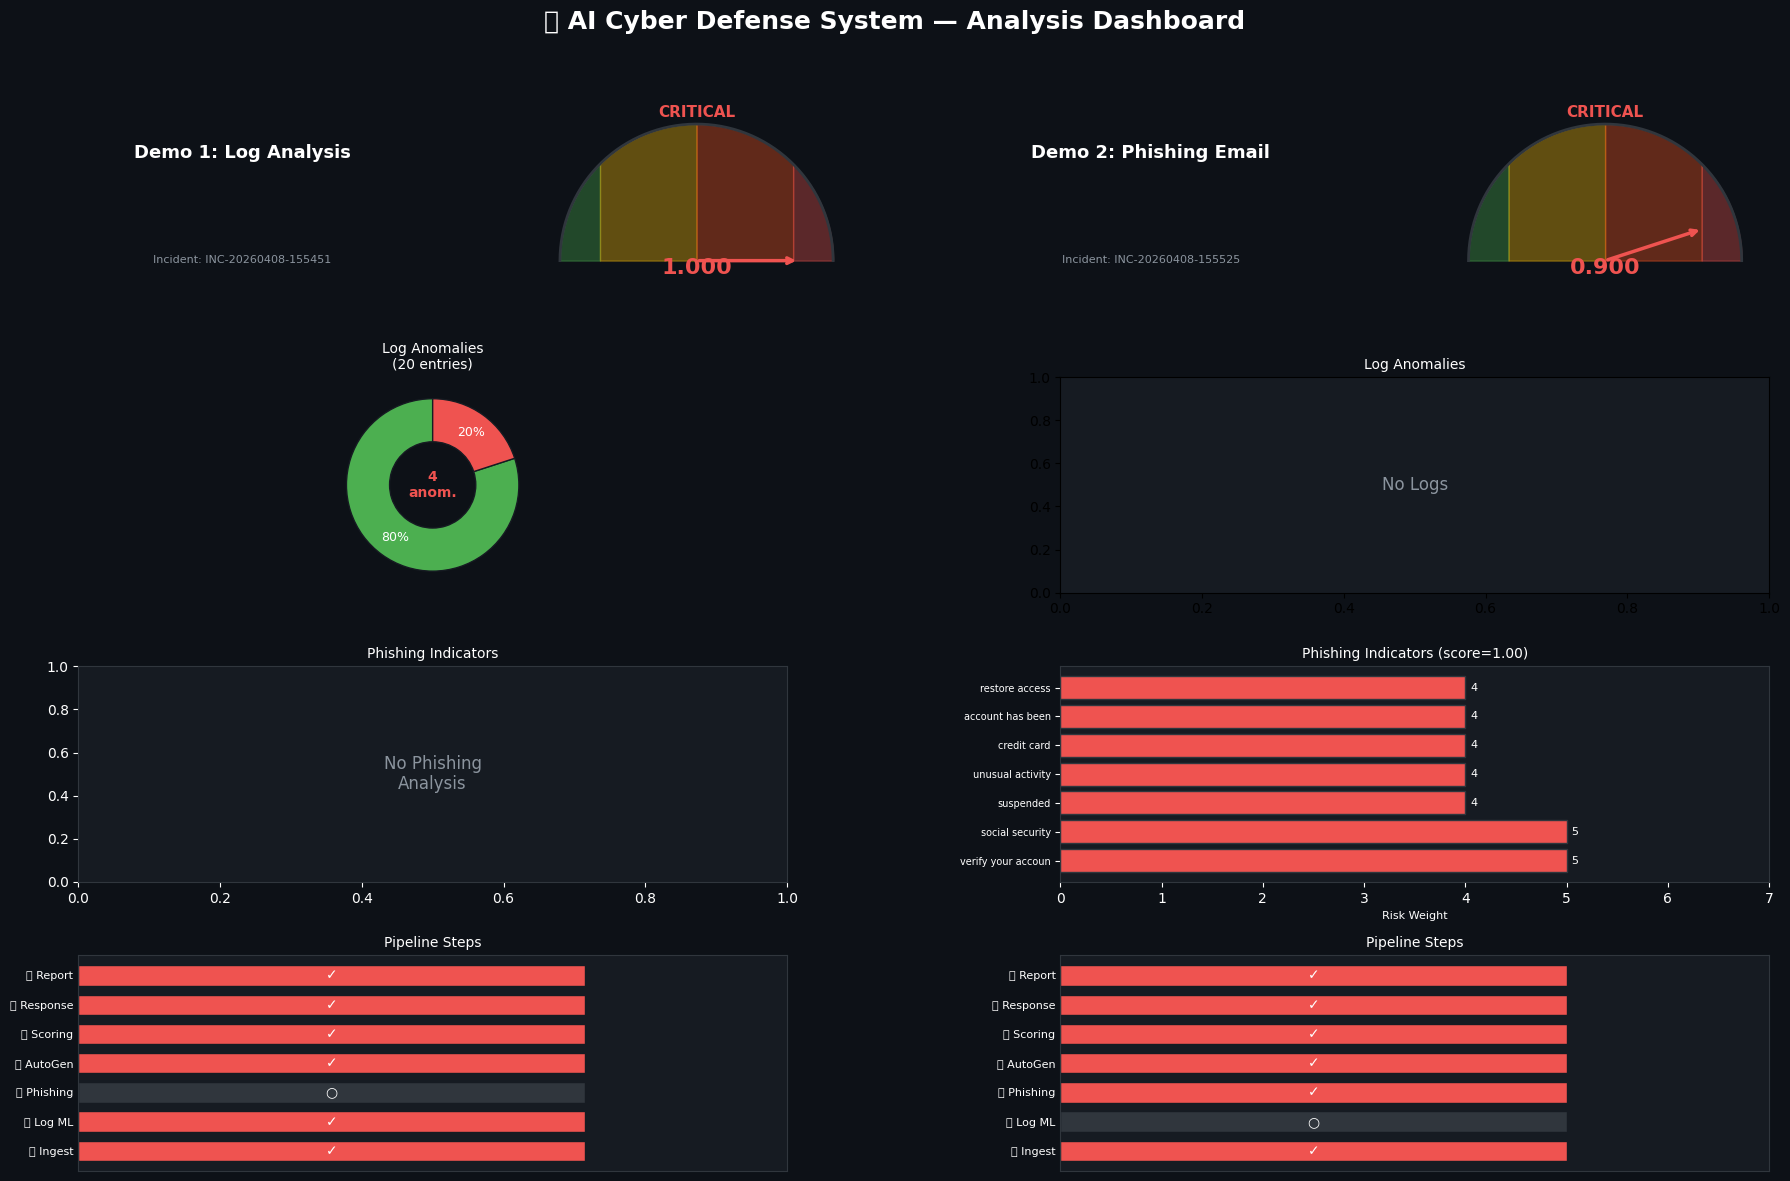

📊 Dashboard saved → /content/cyber_dashboard.png


In [ ]:
def plot_explainer(states: List[Dict], titles: List[str]):
    n = len(states)
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor("#0d1117")
    suptitle = fig.suptitle("🛡️ AI Cyber Defense System — Analysis Dashboard",
                             fontsize=18, fontweight="bold", color="white", y=0.98)

    LEVEL_COLOR = {"LOW":"#4CAF50","MEDIUM":"#FFC107","HIGH":"#FF5722","CRITICAL":"#EF5350"}
    BG   = "#161b22"
    GRID = "#30363d"

    for col, (state, title) in enumerate(zip(states, titles)):
        level  = state.get("threat_level", "LOW")
        score  = state.get("threat_score", 0.0)
        color  = LEVEL_COLOR[level]
        ar     = state.get("anomaly_results", {})
        pr     = state.get("phishing_results", {})
        ti     = state.get("threat_intel_hits", [])
        disc   = state.get("agent_discussion", [])
        recs   = state.get("recommendations", [])

        # ── Row 0: Title badge ────────────────────────────────────────────
        ax0 = fig.add_subplot(4, n*2, col*2 + 1)
        ax0.set_facecolor(BG)
        ax0.text(0.5, 0.7, title, ha="center", va="center",
                 fontsize=13, fontweight="bold", color="white",
                 transform=ax0.transAxes)
        ax0.text(0.5, 0.2, f"Incident: {state.get('incident_id','N/A')}",
                 ha="center", va="center", fontsize=8, color="#8b949e",
                 transform=ax0.transAxes)
        ax0.axis("off")

        # ── Row 0b: Threat gauge ──────────────────────────────────────────
        axg = fig.add_subplot(4, n*2, col*2 + 2)
        axg.set_facecolor(BG)
        theta = np.linspace(np.pi, 0, 200)
        for (s0,s1,c) in [(0,.25,"#4CAF50"),(0.25,.5,"#FFC107"),(0.5,.75,"#FF5722"),(0.75,1,"#EF5350")]:
            t = np.linspace(np.pi*(1-s0), np.pi*(1-s1), 50)
            axg.fill_between(np.cos(t), 0, np.sin(t), alpha=0.35, color=c)
        axg.plot(np.cos(theta), np.sin(theta), color="#30363d", lw=2)
        na = np.pi*(1-score)
        axg.annotate("", xy=(0.75*np.cos(na), 0.75*np.sin(na)), xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
        axg.text(0, -0.1, f"{score:.3f}", ha="center", fontsize=16,
                 fontweight="bold", color=color)
        axg.text(0, 1.05, level, ha="center", fontsize=11,
                 fontweight="bold", color=color)
        axg.set_xlim(-1.2,1.2); axg.set_ylim(-0.25,1.2)
        axg.set_aspect("equal"); axg.axis("off")
        axg.set_facecolor(BG)

        # ── Row 1: Log anomaly pie ────────────────────────────────────────
        ax1 = fig.add_subplot(4, n, n + col + 1)
        ax1.set_facecolor(BG)
        if ar.get("total_entries", 0) > 0:
            tot  = ar["total_entries"]
            anom = ar["anomaly_count"]
            norm = tot - anom
            wedge_props = dict(width=0.5, edgecolor=BG)
            ax1.pie([norm, anom], colors=["#4CAF50","#EF5350"],
                    wedgeprops=wedge_props, startangle=90,
                    autopct="%1.0f%%", pctdistance=0.75,
                    textprops={"color":"white","fontsize":9})
            ax1.text(0, 0, f"{anom}\nanom.", ha="center", va="center",
                     fontsize=10, fontweight="bold", color="#EF5350")
            ax1.set_title(f"Log Anomalies\n({tot} entries)", color="white", fontsize=10)
        else:
            ax1.text(0.5,0.5,"No Logs", ha="center",va="center",
                     color="#8b949e",fontsize=12,transform=ax1.transAxes)
            ax1.set_title("Log Anomalies", color="white", fontsize=10)

        # ── Row 2: Phishing keyword bars ──────────────────────────────────
        ax2 = fig.add_subplot(4, n, 2*n + col + 1)
        ax2.set_facecolor(BG)
        ax2.tick_params(colors="white")
        ax2.spines[:].set_color(GRID)
        kws = pr.get("triggered_keywords", [])[:7]
        if kws:
            labels  = [k["keyword"][:18] for k in kws]
            weights = [k["weight"] for k in kws]
            bar_colors = ["#EF5350" if w>=4 else "#FFC107" for w in weights]
            bars = ax2.barh(labels, weights, color=bar_colors, edgecolor=GRID)
            ax2.set_facecolor(BG)
            ax2.set_xlabel("Risk Weight", color="white", fontsize=8)
            ax2.set_title(
                f"Phishing Indicators (score={pr.get('phishing_score',0):.2f})",
                color="white", fontsize=10)
            for bar, w in zip(bars, weights):
                ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                         str(w), va="center", color="white", fontsize=8)
            ax2.set_xlim(0, 7)
            ax2.tick_params(axis="y", labelcolor="white", labelsize=7)
            ax2.tick_params(axis="x", labelcolor="white")
        else:
            ax2.text(0.5,0.5,"No Phishing\nAnalysis",ha="center",va="center",
                     color="#8b949e",fontsize=12,transform=ax2.transAxes)
            ax2.set_title("Phishing Indicators", color="white", fontsize=10)

        # ── Row 3: Pipeline completion ────────────────────────────────────
        ax3 = fig.add_subplot(4, n, 3*n + col + 1)
        ax3.set_facecolor(BG)
        all_steps = ["ingest","log_analysis","phishing_detection",
                     "agent_analysis","threat_scoring","response_generation","report_generation"]
        labels3   = ["📥 Ingest","🔍 Log ML","🎣 Phishing",
                     "🤖 AutoGen","📊 Scoring","💡 Response","📄 Report"]
        done = state.get("steps_completed",[])
        bar_c = [color if s in done else "#30363d" for s in all_steps]
        ypos  = list(range(len(all_steps)))
        ax3.barh(ypos, [1]*len(all_steps), color=bar_c, edgecolor=BG, height=0.7)
        ax3.set_yticks(ypos)
        ax3.set_yticklabels(labels3, fontsize=8, color="white")
        ax3.set_xticks([]); ax3.set_xlim(0, 1.4)
        ax3.tick_params(axis="y", length=0)
        ax3.spines[:].set_color(GRID)
        for s, y in zip(all_steps, ypos):
            txt = "✓" if s in done else "○"
            ax3.text(0.5, y, txt, ha="center", va="center",
                     color="white", fontweight="bold", fontsize=10)
        ax3.set_title("Pipeline Steps", color="white", fontsize=10)
        ax3.set_facecolor(BG)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("/content/cyber_dashboard.png", dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    print("📊 Dashboard saved → /content/cyber_dashboard.png")


# ── Run the explainer ─────────────────────────────────────────────────────────
plot_explainer(
    states=[log_result, email_result],
    titles=["Demo 1: Log Analysis", "Demo 2: Phishing Email"]
)

## 🤖 Step 11: AutoGen Agent Discussion Explainer


In [ ]:
def print_agent_discussion(state: Dict, title: str = ""):
    """Pretty-print the multi-agent SOC discussion"""
    disc = state.get("agent_discussion", [])
    if not disc:
        print("No agent discussion found.")
        return
    sep = "─" * 62
    print(f"\n╔{"═"*62}╗")
    print(f"║  🤖 AUTOGEN MULTI-AGENT SOC DISCUSSION{" "*(22-len(title))}{title}  ║")
    print(f"╚{"═"*62}╝")
    agent_colors = {
        "CyberAnalyst 🔍": "🔵",
        "SecurityCritic 🛡️": "🟡",
        "SOC_Manager ⚡": "🔴"
    }
    role_desc = {
        "CyberAnalyst 🔍": "THREAT ASSESSMENT",
        "SecurityCritic 🛡️": "VALIDATION & REVIEW",
        "SOC_Manager ⚡": "FINAL DECISION"
    }
    for i, turn in enumerate(disc, 1):
        agent = turn["agent"]
        msg   = turn["message"]
        icon  = agent_colors.get(agent, "⚪")
        role  = role_desc.get(agent, "ANALYSIS")
        print(f"\n  ROUND {i} │ {icon} {agent}")
        print(f"  {"─"*58}")
        print(f"  Role: {role}")
        print(f"  Response:")
        # Word-wrap at 55 chars
        words = msg.split()
        line, lines = "", []
        for w in words:
            if len(line) + len(w) + 1 > 55:
                lines.append(line)
                line = w
            else:
                line = (line + " " + w).strip()
        if line: lines.append(line)
        for l in lines:
            print(f"    {l}")
    threat_level = state.get("threat_level","?")
    threat_score = state.get("threat_score", 0)
    print(f"\n  {"─"*62}")
    print(f"  📊 FINAL CONSENSUS: {threat_level} (score: {threat_score:.3f})")
    print(f"  {"─"*62}\n")

print_agent_discussion(log_result,   title="LOGS")
print_agent_discussion(email_result, title="EMAIL")


╔══════════════════════════════════════════════════════════════╗
║  🤖 AUTOGEN MULTI-AGENT SOC DISCUSSION                  LOGS  ║
╚══════════════════════════════════════════════════════════════╝

  ROUND 1 │ 🔵 CyberAnalyst 🔍
  ──────────────────────────────────────────────────────────
  Role: THREAT ASSESSMENT
  Response:
    The analysis shows that the system has been targeted by
    a web attack that attempts to exploit SQL injection
    vulnerabilities. This is a high severity threat that
    could compromise sensitive data or enable further
    attacks. The source IP addresses indicate that the
    attacker is trying to establish a connection with an
    internal host, possibly to launch a denial of service
    or a remote code execution attack. The exit node and
    the c2 command suggest that the attacker is using Tor
    to hide their identity and location. The system should
    be isolated from the internet and scanned for any
    vulnerabilities or backdoors.

  ROUND 2 │ 🟡 S

## 🌐 Step 12: Interactive Gradio Dashboard

> **Run this cell last** — launches a local web UI you can share with `share=True`


In [ ]:
import gradio as gr

_INIT = {
    "parsed_logs": [], "anomaly_results": {}, "phishing_results": {},
    "threat_intel_hits": [], "agent_discussion": [],
    "threat_level": "LOW", "threat_score": 0.0,
    "recommendations": [], "incident_id": "", "final_report": "",
    "steps_completed": [], "errors": []
}

def run_analysis(input_type_label: str, user_input: str) -> tuple:
    if not user_input.strip():
        return "❌ Please provide input data.", "", "", 0.0
    type_map = {"🔍 Log Analysis": "logs", "📧 Email / Phishing": "email"}
    itype = type_map.get(input_type_label, "logs")
    try:
        result = app.invoke({**_INIT, "input_type": itype, "raw_input": user_input})
        report = result["final_report"]
        disc_lines = []
        for d in result["agent_discussion"]:
            disc_lines.append(f"[{d['agent']}]")
            disc_lines.append(d["message"])
            disc_lines.append("")
        discussion = "\n".join(disc_lines)
        recs = "\n".join(result.get("recommendations", []))
        score = result["threat_score"]
        return report, discussion, recs, score
    except Exception as e:
        return f"❌ Pipeline error: {e}", "", "", 0.0

def load_sample(label):
    return SAMPLE_EMAIL if "Email" in label else SAMPLE_LOGS

with gr.Blocks(
    title="AI Cyber Defense System",
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate",
    ),
    css="""
        body { background: #0d1117 !important; }
        .gradio-container { max-width: 1200px !important; }
        .panel { background: #161b22 !important; border: 1px solid #30363d !important; }
    """
) as demo:

    gr.Markdown("""
    # 🛡️ AI Cyber Defense System
    **Multi-Agent Cybersecurity Pipeline | LangGraph + AutoGen + HuggingFace**

    > Analyze system logs and phishing emails using AI agents powered by TinyLlama
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Input")
            analysis_type = gr.Radio(
                choices=["🔍 Log Analysis", "📧 Email / Phishing"],
                value="🔍 Log Analysis",
                label="Select Analysis Type"
            )
            input_box = gr.Textbox(
                lines=14, label="Input Data",
                placeholder="Paste system logs or email content here...",
                elem_classes=["panel"]
            )
            with gr.Row():
                sample_btn  = gr.Button("📋 Load Sample", variant="secondary")
                analyze_btn = gr.Button("🚀 Analyze Now", variant="primary", scale=2)
            threat_slider = gr.Slider(
                minimum=0, maximum=1, value=0, step=0.001,
                label="🎯 Threat Score (0=Safe, 1=Critical)",
                interactive=False
            )

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Results")
            with gr.Tabs():
                with gr.Tab("📄 Incident Report"):
                    report_box = gr.Textbox(
                        lines=22, label="Full Report",
                        interactive=False, elem_classes=["panel"]
                    )
                with gr.Tab("🤖 Agent Discussion"):
                    discussion_box = gr.Textbox(
                        lines=22, label="AutoGen Agent Chat",
                        interactive=False, elem_classes=["panel"]
                    )
                with gr.Tab("💡 Recommendations"):
                    recs_box = gr.Textbox(
                        lines=22, label="Action Items",
                        interactive=False, elem_classes=["panel"]
                    )

    gr.Markdown("""
    ---
    **Architecture:** `Input → Ingest → Log/Phishing Analysis → AutoGen 3-Agent Discussion → Threat Scoring → Recommendations → Report`

    **Models:** TinyLlama-1.1B (HF) | **Detection:** Isolation Forest | **Agents:** Analyst + Critic + SOC Manager
    """)

    analyze_btn.click(
        fn=run_analysis,
        inputs=[analysis_type, input_box],
        outputs=[report_box, discussion_box, recs_box, threat_slider]
    )
    sample_btn.click(
        fn=load_sample,
        inputs=[analysis_type],
        outputs=[input_box]
    )

demo.launch(share=True, debug=False, quiet=True)
print("🌐 Gradio UI launched! Click the link above to open.")

* Running on public URL: https://bfb70e3d95a078e7c7.gradio.live


🌐 Gradio UI launched! Click the link above to open.
